In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import shap

### Load data

In [4]:
df = pd.read_csv('data/train_0irEZ2H.csv')


In [5]:
df.head()

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [7]:
df.isnull().sum()

record_ID          0
week               0
store_id           0
sku_id             0
total_price        1
base_price         0
is_featured_sku    0
is_display_sku     0
units_sold         0
dtype: int64

In [8]:
df[df['total_price']. isnull()]

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
136949,193915,23/04/13,9436,245338,NaN,469.5375,0,0,1


In [9]:
df['total_price'] = df['total_price'].fillna(df['total_price'].mean())

In [10]:
df[df['total_price'].isnull()]

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold


In [11]:
df[['day', 'month', 'year']] = df['week'].str.split('/', expand=True)

In [12]:
df = df.drop(['week'], axis=1)

In [13]:
df

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year
0,1,8091,216418,99.0375,111.8625,0,0,20,17,01,11
1,2,8091,216419,99.0375,99.0375,0,0,28,17,01,11
2,3,8091,216425,133.9500,133.9500,0,0,19,17,01,11
3,4,8091,216233,133.9500,133.9500,0,0,44,17,01,11
4,5,8091,217390,141.0750,141.0750,0,0,52,17,01,11
...,...,...,...,...,...,...,...,...,...,...,...
150145,212638,9984,223245,235.8375,235.8375,0,0,38,09,07,13
150146,212639,9984,223153,235.8375,235.8375,0,0,30,09,07,13
150147,212642,9984,245338,357.6750,483.7875,1,1,31,09,07,13
150148,212643,9984,547934,141.7875,191.6625,0,1,12,09,07,13


In [14]:
X = df.drop(['units_sold'], axis=1)
y = df['units_sold']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train[['day', 'month', 'year']] = X_train[['day', 'month', 'year']].apply(pd.to_numeric, errors='coerce')
X_test[['day', 'month', 'year']] = X_test[['day', 'month', 'year']].apply(pd.to_numeric, errors='coerce')

In [17]:
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
# Predicting on the test set
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2_score)

MAE: 16.42365837097168
RMSE: 27.862661051295422
R²: 0.7633959054946899


In [19]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)



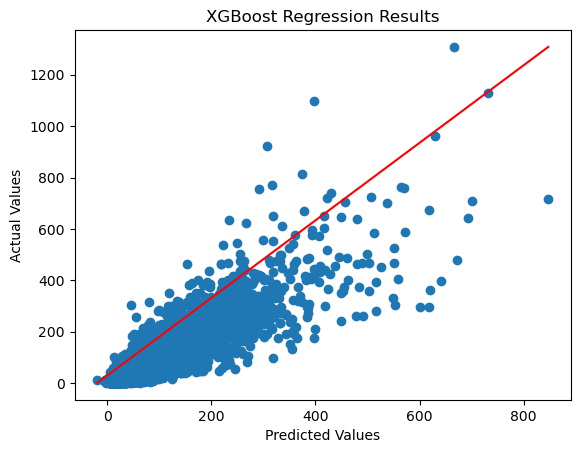

In [20]:
# Visualizing the results
plt.scatter(y_pred, y_test) 
plt.plot(np.linspace(y_pred.min(), y_pred.max()), np.linspace(y_test.min(), y_test.max()), color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('XGBoost Regression Results')
plt.show()

In [21]:
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("Cross-Validation R² Scores:", scores)
print("Mean R² Score:", scores.mean())
print("Standard Deviation of R² Scores:", scores.std())

Cross-Validation R² Scores: [0.74275661 0.75154722 0.73705149 0.75464082 0.74972177]
Mean R² Score: 0.7471435785293579
Standard Deviation of R² Scores: 0.0063772019727170205


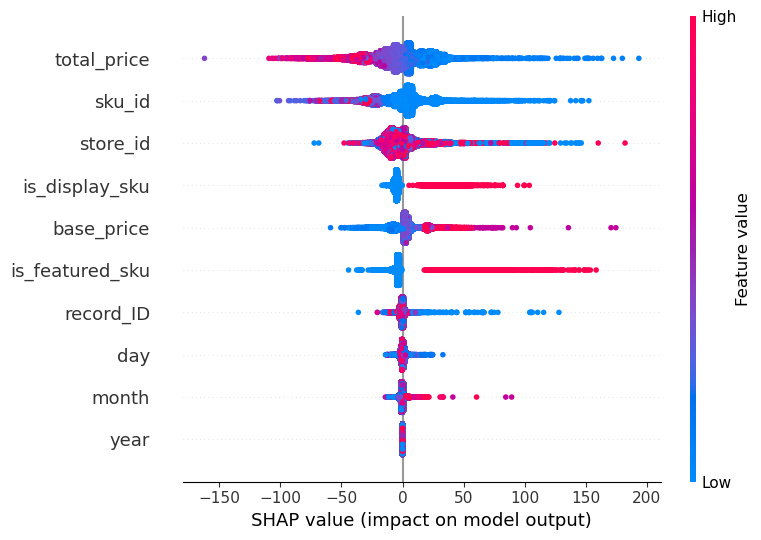

In [22]:
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)


count    150150.000000
mean         51.674206
std          60.207904
min           1.000000
25%          20.000000
50%          35.000000
75%          62.000000
max        2876.000000
Name: units_sold, dtype: float64

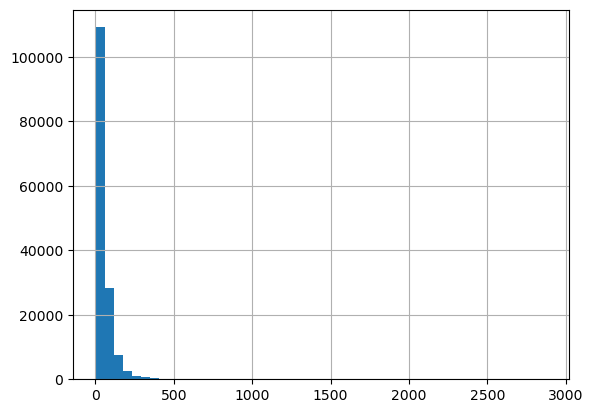

In [23]:
df.units_sold.hist(bins=50)
df.units_sold.describe()

In [24]:
# Predict demand for the next month

def forecast_next_30_days(model, df, features):

    history = df.copy()

    history = history.sort_values(
        ["store_id", "sku_id", "date"]
    ).reset_index(drop=True)

    last_date = history["date"].max()

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    store_sku_pairs = (
        history[
            ["store_id", "sku_id"]
        ]
        .drop_duplicates()
    )

    all_predictions = []

    for future_date in future_dates:

        future_rows = []

        for _, pair in store_sku_pairs.iterrows():

            store = pair["store_id"]
            sku = pair["sku_id"]

            product_history = history[
                (history["store_id"] == store) &
                (history["sku_id"] == sku)
            ].sort_values("date")

            # Skip if not enough history
            if len(product_history) < 28:
                continue

            # ---------------------------------
            # Demand-history features
            # ---------------------------------

            lag_1 = product_history[
                "units_sold"
            ].iloc[-1]

            lag_7 = product_history[
                "units_sold"
            ].iloc[-7]

            lag_14 = product_history[
                "units_sold"
            ].iloc[-14]

            lag_28 = product_history[
                "units_sold"
            ].iloc[-28]

            rolling_mean_7 = (
                product_history["units_sold"]
                .iloc[-7:]
                .mean()
            )

            rolling_mean_14 = (
                product_history["units_sold"]
                .iloc[-14:]
                .mean()
            )

            rolling_mean_28 = (
                product_history["units_sold"]
                .iloc[-28:]
                .mean()
            )

            rolling_std_7 = (
                product_history["units_sold"]
                .iloc[-7:]
                .std()
            )

            # ---------------------------------
            # Future price information
            # ---------------------------------

            # Here we're assuming future price
            # remains equal to most recent price.
            # Replace this if you know planned prices.

            total_price = product_history[
                "total_price"
            ].iloc[-1]

            base_price = product_history[
                "base_price"
            ].iloc[-1]

            discount = (
                (base_price - total_price)
                / base_price
                if base_price != 0
                else 0
            )

            # ---------------------------------
            # Promotion information
            # ---------------------------------

            # Assumption: not featured/displayed
            # unless you know future promotion plans.

            is_featured_sku = 0
            is_display_sku = 0

            row = {
                "store_id": store,
                "sku_id": sku,

                "total_price": total_price,
                "base_price": base_price,
                "discount": discount,

                "is_featured_sku": is_featured_sku,
                "is_display_sku": is_display_sku,

                "day": future_date.day,
                "month": future_date.month,
                "year": future_date.year,

                "day_of_week": future_date.dayofweek,

                "week_of_year":
                    future_date.isocalendar().week,

                "lag_1": lag_1,
                "lag_7": lag_7,
                "lag_14": lag_14,
                "lag_28": lag_28,

                "rolling_mean_7": rolling_mean_7,
                "rolling_mean_14": rolling_mean_14,
                "rolling_mean_28": rolling_mean_28,

                "rolling_std_7": rolling_std_7,

                "date": future_date
            }

            future_rows.append(row)

        future_df = pd.DataFrame(future_rows)

        if future_df.empty:
            continue

        # XGBoost prediction
        future_df["predicted_units_sold"] = (
            model.predict(
                future_df[features]
            )
        )

        # Demand should not be negative
        future_df["predicted_units_sold"] = (
            future_df[
                "predicted_units_sold"
            ]
            .clip(lower=0)
        )

        all_predictions.append(
            future_df[
                [
                    "date",
                    "store_id",
                    "sku_id",
                    "predicted_units_sold"
                ]
            ]
        )

        # -----------------------------------
        # Add prediction back into history
        # -----------------------------------

        new_history = future_df.copy()

        new_history["units_sold"] = (
            new_history[
                "predicted_units_sold"
            ]
        )

        history = pd.concat(
            [history, new_history],
            ignore_index=True
        )

    return pd.concat(
        all_predictions,
        ignore_index=True
    )


In [ ]:
def forecast_next_30_days(model, df, features):

    history = df.copy()

    history = history.sort_values(
        ["store_id", "sku_id", "date"]
    ).reset_index(drop=True)

    last_date = history["date"].max()

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    store_sku_pairs = (
        history[
            ["store_id", "sku_id"]
        ]
        .drop_duplicates()
    )

    all_predictions = []

    for future_date in future_dates:

        future_rows = []

        for _, pair in store_sku_pairs.iterrows():

            store = pair["store_id"]
            sku = pair["sku_id"]

            product_history = history[
                (history["store_id"] == store) &
                (history["sku_id"] == sku)
            ].sort_values("date")

            # Skip if not enough history
            if len(product_history) < 28:
                continue

            # ---------------------------------
            # Demand-history features
            # ---------------------------------

            lag_1 = product_history[
                "units_sold"
            ].iloc[-1]

            lag_7 = product_history[
                "units_sold"
            ].iloc[-7]

            lag_14 = product_history[
                "units_sold"
            ].iloc[-14]

            lag_28 = product_history[
                "units_sold"
            ].iloc[-28]

            rolling_mean_7 = (
                product_history["units_sold"]
                .iloc[-7:]
                .mean()
            )

            rolling_mean_14 = (
                product_history["units_sold"]
                .iloc[-14:]
                .mean()
            )

            rolling_mean_28 = (
                product_history["units_sold"]
                .iloc[-28:]
                .mean()
            )

            rolling_std_7 = (
                product_history["units_sold"]
                .iloc[-7:]
                .std()
            )

            # ---------------------------------
            # Future price information
            # ---------------------------------

            # Here we're assuming future price
            # remains equal to most recent price.
            # Replace this if you know planned prices.

            total_price = product_history[
                "total_price"
            ].iloc[-1]

            base_price = product_history[
                "base_price"
            ].iloc[-1]

            discount = (
                (base_price - total_price)
                / base_price
                if base_price != 0
                else 0
            )

            # ---------------------------------
            # Promotion information
            # ---------------------------------

            # Assumption: not featured/displayed
            # unless you know future promotion plans.

            is_featured_sku = 0
            is_display_sku = 0

            row = {
                "store_id": store,
                "sku_id": sku,

                "total_price": total_price,
                "base_price": base_price,
                "discount": discount,

                "is_featured_sku": is_featured_sku,
                "is_display_sku": is_display_sku,

                "day": future_date.day,
                "month": future_date.month,
                "year": future_date.year,

                "day_of_week": future_date.dayofweek,

                "week_of_year":
                    future_date.isocalendar().week,

                "lag_1": lag_1,
                "lag_7": lag_7,
                "lag_14": lag_14,
                "lag_28": lag_28,

                "rolling_mean_7": rolling_mean_7,
                "rolling_mean_14": rolling_mean_14,
                "rolling_mean_28": rolling_mean_28,

                "rolling_std_7": rolling_std_7,

                "date": future_date
            }

            future_rows.append(row)

        future_df = pd.DataFrame(future_rows)

        if future_df.empty:
            continue

        # XGBoost prediction
        future_df["predicted_units_sold"] = (
            model.predict(
                future_df[features]
            )
        )

        # Demand should not be negative
        future_df["predicted_units_sold"] = (
            future_df[
                "predicted_units_sold"
            ]
            .clip(lower=0)
        )

        all_predictions.append(
            future_df[
                [
                    "date",
                    "store_id",
                    "sku_id",
                    "predicted_units_sold"
                ]
            ]
        )

        # -----------------------------------
        # Add prediction back into history
        # -----------------------------------

        new_history = future_df.copy()

        new_history["units_sold"] = (
            new_history[
                "predicted_units_sold"
            ]
        )

        history = pd.concat(
            [history, new_history],
            ignore_index=True
        )

    return pd.concat(
        all_predictions,
        ignore_index=True
    )

In [26]:
features = [
    "store_id",
    "sku_id",

    "total_price",
    "base_price",
    "discount",

    "is_featured_sku",
    "is_display_sku",

    "day",
    "month",
    "year",
    "day_of_week",
    "week_of_year",

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7"
]
forecast = forecast_next_30_days(
    model,
    df,
    features
)

print(forecast.head(20))

KeyError: 'date'